# OffScript — Phase 2: Baseline Pitch Selection Model

This notebook trains an XGBoost classifier to predict pitch type from game
context features. The model is not intended to predict pitch selection
perfectly — it establishes a statistical baseline that defines what
"conventional" pitch selection looks like, against which individual pitcher
deviations are measured in Phase 3.

**Goals:**
- Engineer context features from the cleaned Statcast dataset
- Train a multi-class XGBoost classifier with class-weight balancing
- Evaluate model performance and interpret feature importance via SHAP
- Persist the trained model and encoders for use in Phase 3

**Input:** `data/processed/pitcher_data_clean.parquet`  
**Output:** `models/baseline_pitch_model.pkl`, `models/label_encoder.pkl`, `models/pitcher_encoder.pkl`

## 1. Setup

In [1]:
import sys
sys.path.append("../src")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import xgboost as xgb

from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

from pitch_analysis import load_clean_data

data = load_clean_data()

print(f"Modeling dataset: {len(data):,} pitches")
print(f"Pitch types:      {sorted(data['pitch_type'].unique())}")

Modeling dataset: 72,098 pitches
Pitch types:      ['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST']


## 2. Feature Engineering & Pitcher Encoding

Pitcher name is encoded as a numeric label first since it is referenced
in the feature matrix below. The encoder is persisted alongside the model
for consistent use in Phase 3 and Phase 5.

Features fall into three groups:

| Group | Features | Rationale |
|---|---|---|
| Count state | `balls`, `strikes`, `count_leverage` | Primary situational driver |
| Game context | `inning`, `score_diff` | Macro-level strategic pressure |
| Baserunners | `on_1b`, `on_2b`, `on_3b`, `runners_on`, `scoring_position` | Runner configuration |
| Batter/pitcher | `stand_encoded`, `pitcher_encoded` | Handedness and arsenal tendencies |

In [2]:
# ── Pitcher Identity Encoding ───────────────────────────────────────────────
pitcher_encoder = LabelEncoder()
data["pitcher_encoded"] = pitcher_encoder.fit_transform(data["pitcher_name"])

os.makedirs("../models", exist_ok=True)
joblib.dump(pitcher_encoder, "../models/pitcher_encoder.pkl")

print("=== Pitcher Encoding ===")
for name, code in zip(pitcher_encoder.classes_, range(len(pitcher_encoder.classes_))):
    print(f"  {name}: {code}")

# ── Batter Handedness ────────────────────────────────────────────────────────
data["stand_encoded"] = (data["stand"] == "R").astype(int)

# ── Baserunner Aggregate Features ───────────────────────────────────────────
data["runners_on"] = (
    data["on_1b"].fillna(0) + data["on_2b"].fillna(0) + data["on_3b"].fillna(0)
)
data["scoring_position"] = (
    (data["on_2b"].fillna(0) + data["on_3b"].fillna(0)) > 0
).astype(int)

# ── Count Leverage ───────────────────────────────────────────────────────────
data["count_leverage"] = (
    (data["strikes"] == 2).astype(int) * 2
    + (data["balls"] == 3).astype(int) * 2
    + (data["strikes"] == 1).astype(int)
    + (data["balls"] == 2).astype(int)
)

# ── Feature Column List ──────────────────────────────────────────────────────
FEATURE_COLS = [
    "balls", "strikes", "inning", "score_diff",
    "on_1b", "on_2b", "on_3b",
    "runners_on", "scoring_position",
    "stand_encoded", "pitcher_encoded", "count_leverage",
]

print("\n=== Feature Matrix Preview ===")
print(data[FEATURE_COLS].describe())

=== Pitcher Encoding ===
  Chris Sale: 0
  Corbin Burnes: 1
  Dylan Cease: 2
  Framber Valdez: 3
  Gerrit Cole: 4
  Justin Verlander: 5
  Kyle Hendricks: 6
  Logan Webb: 7
  Marcus Stroman: 8
  Max Scherzer: 9
  Nestor Cortes: 10
  Spencer Strider: 11
  Yusei Kikuchi: 12
  Zack Wheeler: 13

=== Feature Matrix Preview ===
              balls       strikes        inning    score_diff         on_1b  \
count  72098.000000  72098.000000  72098.000000  72098.000000  72098.000000   
mean       0.857902      0.916184      3.513801     -0.155996      0.275195   
std        0.956589      0.829757      1.861111      2.346825      0.446616   
min        0.000000      0.000000      1.000000    -13.000000      0.000000   
25%        0.000000      0.000000      2.000000     -1.000000      0.000000   
50%        1.000000      1.000000      3.000000      0.000000      0.000000   
75%        1.000000      2.000000      5.000000      1.000000      1.000000   
max        3.000000      2.000000     10.0000

### 3. Train/Test Split

Stratified splitting preserves the class distribution of pitch types in both
the training and test sets, which is important given the imbalance between
common pitch types (FF, SL) and rare ones (KC, ST).

In [3]:
X = data[FEATURE_COLS].fillna(0)
le = LabelEncoder()
y = le.fit_transform(data["pitch_type"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print(f"Training samples: {len(X_train):,}")
print(f"Testing samples:  {len(X_test):,}")
print("\n=== Class Distribution in Test Set ===")
print(pd.Series(le.inverse_transform(y_test)).value_counts())

Training samples: 57,678
Testing samples:  14,420

=== Class Distribution in Test Set ===
FF    4757
SL    2108
SI    1750
CH    1715
FC    1413
CU    1376
ST     652
FS     361
KC     288
Name: count, dtype: int64


## 4. Class Weight Balancing

Pitch type distributions are naturally imbalanced — fastballs outnumber
specialty pitches by a wide margin. Class weights are computed to penalise
the model more heavily for misclassifying rare pitch types. Weights are
capped between 0.5 and 2.0 to prevent overcorrection on very rare classes.

In [4]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

# Cap weights to prevent overcorrection on very rare classes
class_weights = np.clip(class_weights, 0.5, 2.0)
sample_weights = class_weights[y_train]

print("=== Adjusted Class Weights ===")
for cls, weight in zip(le.classes_, class_weights):
    count = (y_train == le.transform([cls])[0]).sum()
    print(f"  {cls}: count={count:,}, weight={weight:.3f}")

=== Adjusted Class Weights ===
  CH: count=6,859, weight=0.934
  CU: count=5,503, weight=1.165
  FC: count=5,649, weight=1.134
  FF: count=19,028, weight=0.500
  FS: count=1,446, weight=2.000
  KC: count=1,153, weight=2.000
  SI: count=6,998, weight=0.916
  SL: count=8,432, weight=0.760
  ST: count=2,610, weight=2.000


## 5. Train XGBoost Classifier

In [5]:
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
)

model.fit(X_train, y_train, sample_weight=sample_weights)
y_pred = model.predict(X_test)

print(f"Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy:          0.424
Balanced Accuracy: 0.482

Classification Report:
              precision    recall  f1-score   support

          CH       0.47      0.30      0.36      1715
          CU       0.30      0.30      0.30      1376
          FC       0.44      0.59      0.50      1413
          FF       0.57      0.34      0.43      4757
          FS       0.30      0.79      0.44       361
          KC       0.16      0.50      0.25       288
          SI       0.54      0.51      0.52      1750
          SL       0.43      0.51      0.47      2108
          ST       0.26      0.50      0.34       652

    accuracy                           0.42     14420
   macro avg       0.39      0.48      0.40     14420
weighted avg       0.47      0.42      0.43     14420



## A Note on Model Accuracy

Pitch selection involves intentional deception and randomness by design.
A pitcher who is perfectly predictable would be ineffective at the major
league level. An accuracy meaningfully above random chance (~11% for 9
classes) demonstrates the model has learned real patterns. The goal of
this model is not perfect prediction but rather establishing a statistical
baseline from which individual pitcher deviations can be measured.

## 6. Feature Importance

=== Feature Importance ===
         feature  importance
 pitcher_encoded    0.598485
   stand_encoded    0.133633
         strikes    0.054215
           balls    0.038078
  count_leverage    0.030616
          inning    0.023154
scoring_position    0.021700
           on_1b    0.021481
      runners_on    0.021328
      score_diff    0.020870
           on_3b    0.018737
           on_2b    0.017700


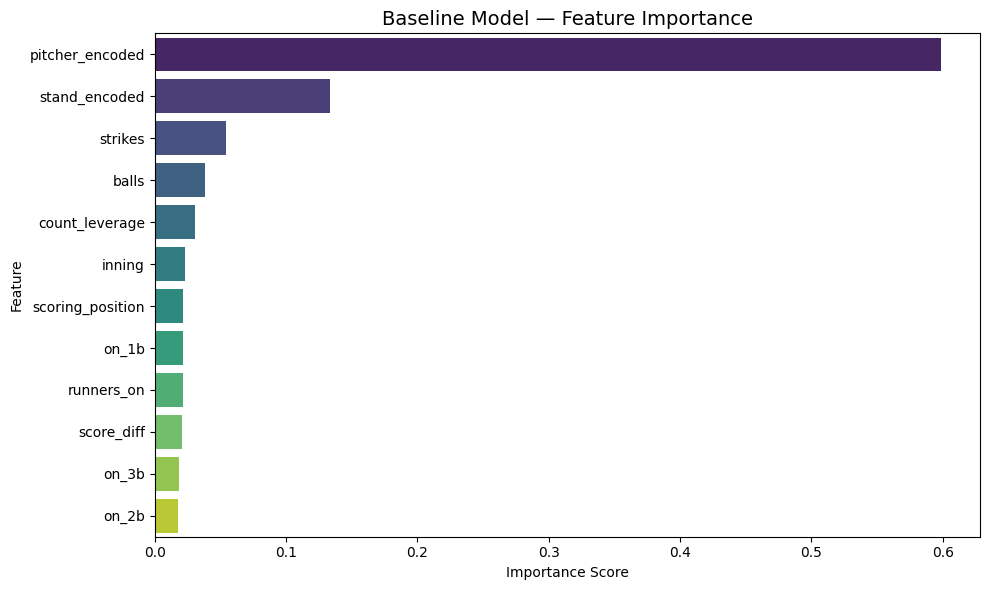

In [6]:
importance_df = (
    pd.DataFrame({"feature": FEATURE_COLS, "importance": model.feature_importances_})
    .sort_values("importance", ascending=False)
)

print("=== Feature Importance ===")
print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    hue="feature",
    legend=False,
    palette="viridis",
    ax=ax,
)
ax.set_title("Baseline Model — Feature Importance", fontsize=14)
ax.set_xlabel("Importance Score")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Confusion Matrix

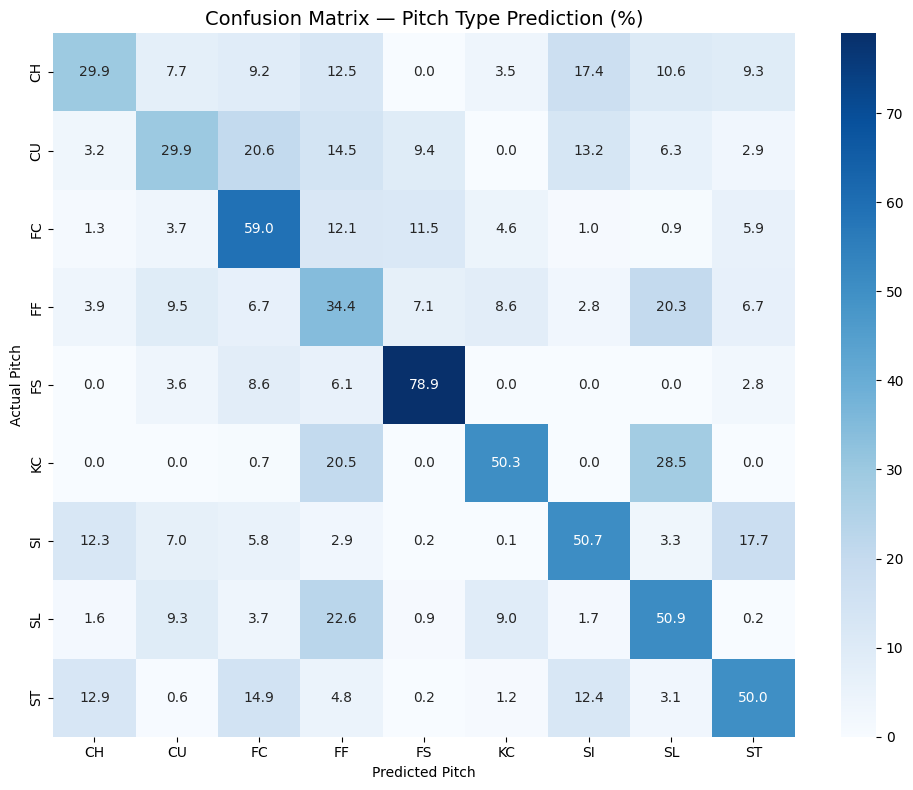

In [7]:
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1)[:, None] * 100

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_pct,
    annot=True,
    fmt=".1f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Confusion Matrix — Pitch Type Prediction (%)", fontsize=14)
ax.set_ylabel("Actual Pitch")
ax.set_xlabel("Predicted Pitch")
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. SHAP Explainability

SHAP (SHapley Additive exPlanations) values quantify each feature's
contribution to individual predictions. The summary plot below shows
which features most consistently drive pitch type predictions across
the test set, and in which direction.

Generating SHAP values — this may take a moment...


<Figure size 1000x600 with 0 Axes>

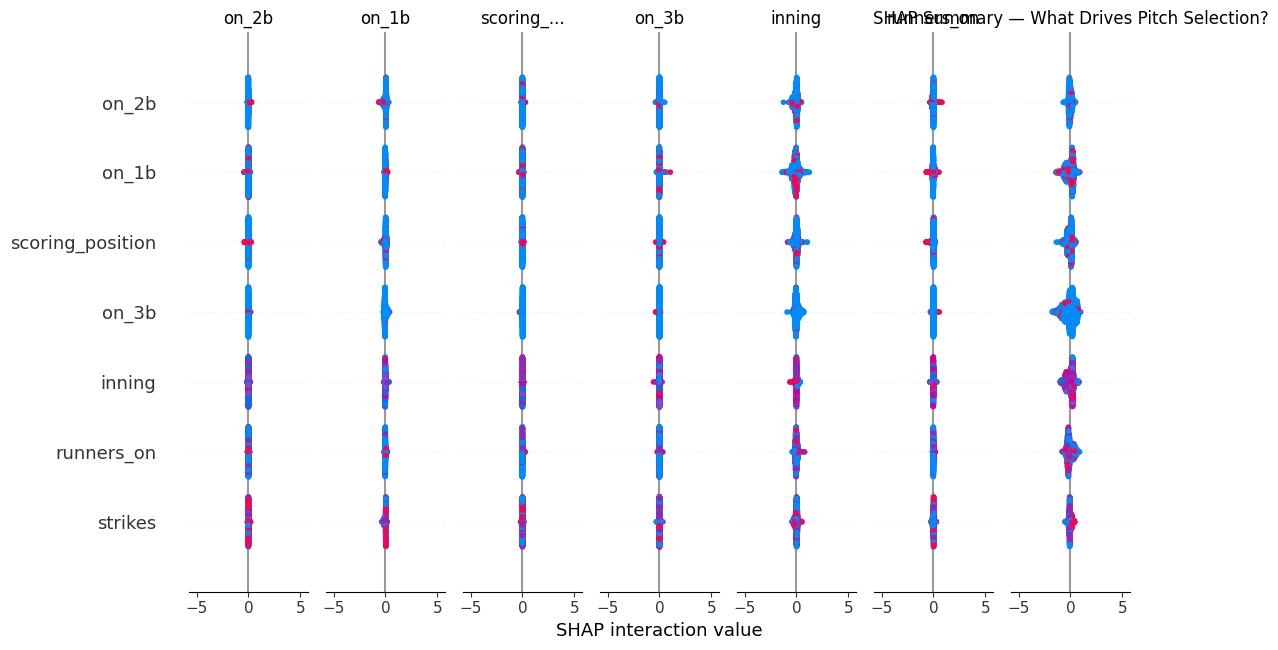

In [8]:
print("Generating SHAP values — this may take a moment...")
explainer = shap.TreeExplainer(model)
shap_sample = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(shap_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    shap_sample,
    feature_names=FEATURE_COLS,
    class_names=le.classes_,
    show=False,
)
plt.title("SHAP Summary — What Drives Pitch Selection?")
plt.tight_layout()
plt.savefig("../reports/figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save Models

In [9]:
os.makedirs("../models", exist_ok=True)

MODEL_DIR = "../models"
artifacts = {
    "baseline_pitch_model.pkl": model,
    "label_encoder.pkl": le,
    "pitcher_encoder.pkl": pitcher_encoder,
}

for filename, obj in artifacts.items():
    path = os.path.join(MODEL_DIR, filename)
    joblib.dump(obj, path)
    print(f"Saved: {path}")

Saved: ../models\baseline_pitch_model.pkl
Saved: ../models\label_encoder.pkl
Saved: ../models\pitcher_encoder.pkl


## 10. Phase 2 Summary Statistics

In [10]:
print(f"Model last run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print("\n=== PHASE 2 SUMMARY STATISTICS ===")

print(f"\nDataset:")
print(f"  Total pitches:    {len(data):,}")
print(f"  Training samples: {len(X_train):,}")
print(f"  Testing samples:  {len(X_test):,}")
print(f"  Pitch types:      {sorted(le.classes_)}")

print(f"\nModel Performance:")
print(f"  Accuracy:          {accuracy_score(y_test, y_pred):.3f}")
print(f"  Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}")

report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
f1_scores = {k: v["f1-score"] for k, v in report.items() if k in le.classes_}

print(f"\nF1 Scores by Pitch Type:")
for pitch, f1 in sorted(f1_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {pitch}: {f1:.3f}")

print(f"\nFeature Importance (top 3):")
for _, row in importance_df.head(3).iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f} ({row['importance'] * 100:.1f}%)")

Model last run: 2026-05-16 10:37

=== PHASE 2 SUMMARY STATISTICS ===

Dataset:
  Total pitches:    72,098
  Training samples: 57,678
  Testing samples:  14,420
  Pitch types:      ['CH', 'CU', 'FC', 'FF', 'FS', 'KC', 'SI', 'SL', 'ST']

Model Performance:
  Accuracy:          0.424
  Balanced Accuracy: 0.482

F1 Scores by Pitch Type:
  SI: 0.525
  FC: 0.502
  SL: 0.468
  FS: 0.439
  FF: 0.429
  CH: 0.365
  ST: 0.343
  CU: 0.299
  KC: 0.248

Feature Importance (top 3):
  pitcher_encoded: 0.598 (59.8%)
  stand_encoded: 0.134 (13.4%)
  strikes: 0.054 (5.4%)


## Phase 2 Results Summary

### Dataset
- **Total pitches modeled:** 72,098 across 15 pitchers (2023–2024)
- **Training samples:** 57,678
- **Testing samples:** 14,420
- **Pitch types:** CH, CU, FC, FF, FS, KC, SI, SL, ST

### Model Performance
- **Accuracy:** 0.424
- **Balanced Accuracy:** 0.482
- **Strongest classes:** SI (0.525), FC (0.502), SL (0.468)
- **Most challenging classes:** KC (0.248), CU (0.299)

### Feature Importance Findings
- **Pitcher identity** is the dominant predictor at 59.8%, confirming
  that individual arsenal and tendencies drive pitch selection more
  than any situational factor
- **Batter handedness** is the strongest situational feature at 13.4%,
  consistent with conventional pitching wisdom
- **Strike count** (5.4%) and **ball count** (3.8%) are the strongest
  pure count features, reflecting how two-strike and three-ball counts
  shift pitch selection

### Interpretation
This baseline model establishes the statistical foundation for deviation
analysis in Phase 3. The dominance of pitcher identity as a feature
raises an important design question for deviation scoring — deviations
can be measured against universal league norms (removing pitcher identity)
or against each pitcher's own tendencies (keeping pitcher identity).
Phase 3 will explore both approaches.

### Model Limitations
- Rare pitch types (KC, ST) remain difficult to predict precisely
  due to limited sample sizes
- Intentional deception is inherent to pitching, creating a natural
  ceiling on predictability
- A balanced accuracy of 0.482 against a random baseline of ~0.111
  for 9 classes represents meaningful signal